---
# authors:
#   - name: Neena Jain
#     affiliations:
#       - emBOLDen LLC
abstract: |
  A practical tutorial for creating publication-quality charts and static visualizations using pandas and matplotlib.
exports:
    - format: typst
      template: lapreprint-typst
      output: export/05-charts.pdf 
--- 

# 5. Charts

Pandas + Matplotlib provide a powerful, flexible approach to data visualization:

**Pandas** excels at:
- Loading and manipulating tabular data
- Quick exploratory data analysis
- Built-in plotting methods

**Matplotlib** excels at:
- Fine-grained control over every visual element
- Publication-quality output
- Integration with scientific Python ecosystem


In [22]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Set style and font sizes for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

# Configure Seaborn for improved aesthetics
sns.set_palette("husl")

# For better display in Jupyter
%matplotlib inline

## Creating Basic Plots

First, let's create a simple dataset.

In [23]:
# Create a sample geospatial dataset
np.random.seed(42)
years = np.arange(2015, 2023)

# Create more illustrative data with clear trends
# The story: As protected areas increase, total forest area is better preserved
data = {
    'Year': years,
    'Forest_Area_km2': 45000 + (years - 2015) * 400 + np.random.normal(0, 300, len(years)),
    'Deforestation_Rate_%': 2.8 - (years - 2015) * 0.12 + np.random.normal(0, 0.15, len(years)),
    'Protected_Area_km2': 12000 + (years - 2015) * 450 + np.random.normal(0, 200, len(years)),
    'Population': 1000000 + (years - 2015) * 50000 + np.random.normal(0, 10000, len(years))
}

df = pd.DataFrame(data)
print("Sample Dataset:")
print(df)

Sample Dataset:
   Year  Forest_Area_km2  Deforestation_Rate_%  Protected_Area_km2  \
0  2015     45149.014246              2.729579        11797.433776   
1  2016     45358.520710              2.761384        12512.849467   
2  2017     45994.306561              2.490487        12718.395185   
3  2018     46656.908957              2.370141        13067.539260   
4  2019     46529.753988              2.356294        14093.129754   
5  2020     46929.758913              1.913008        14204.844740   
6  2021     47873.763845              1.821262        14713.505641   
7  2022     48030.230419              1.875657        14865.050363   

     Population  
0  9.945562e+05  
1  1.051109e+06  
2  1.088490e+06  
3  1.153757e+06  
4  1.193994e+06  
5  1.247083e+06  
6  1.293983e+06  
7  1.368523e+06  


### Line


<Figure size 1000x600 with 0 Axes>

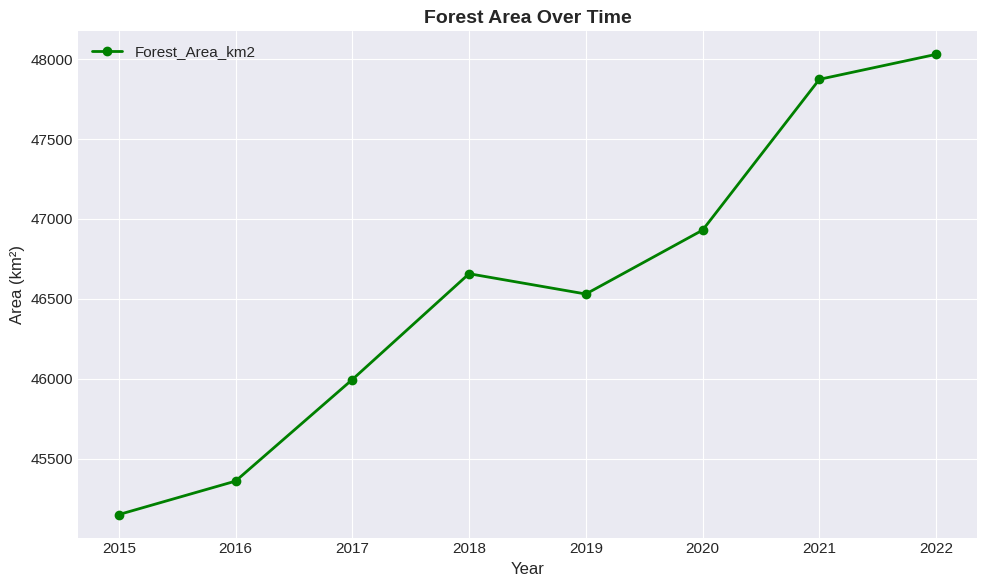

In [24]:
# Simple line plot
plt.figure(figsize=(10, 6))
df.plot(x='Year', y='Forest_Area_km2', kind='line', marker='o', color='green', linewidth=2)

plt.title('Forest Area Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Area (km²)', fontsize=12)
plt.tight_layout()
plt.show()

### Bar

Bar plots are excellent for comparing categories or showing discrete values:


<Figure size 1000x600 with 0 Axes>

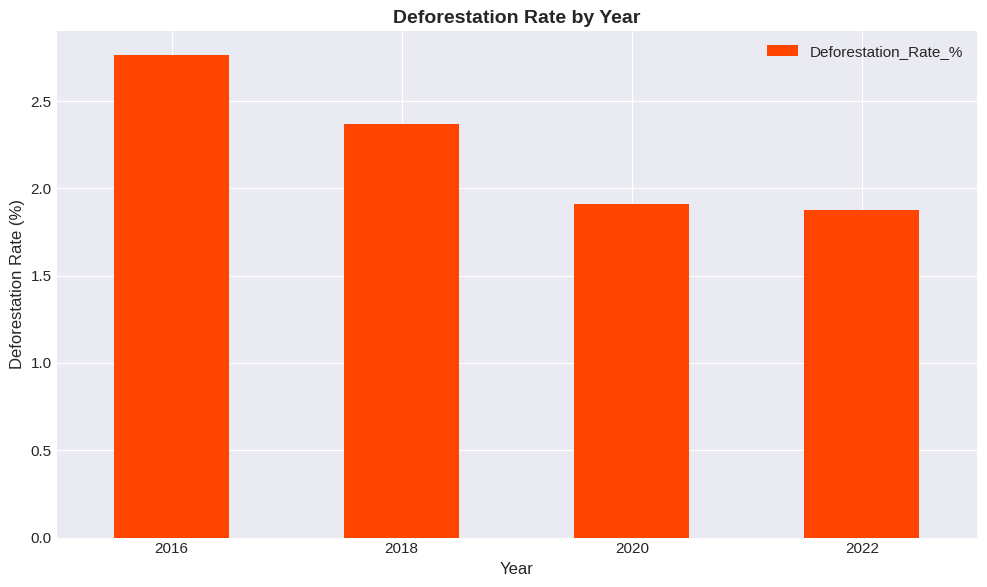

In [25]:
# Bar plot - subset of data
subset_years = df[df['Year'].isin([2016, 2018, 2020, 2022])]

plt.figure(figsize=(10, 6))
subset_years.plot(x='Year', y='Deforestation_Rate_%', kind='bar', color='orangered')

plt.title('Deforestation Rate by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Deforestation Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Scatter Plot
Scatter plots reveal correlations between variables. This simple plot shows the positive relationship between protected areas and total forest area.

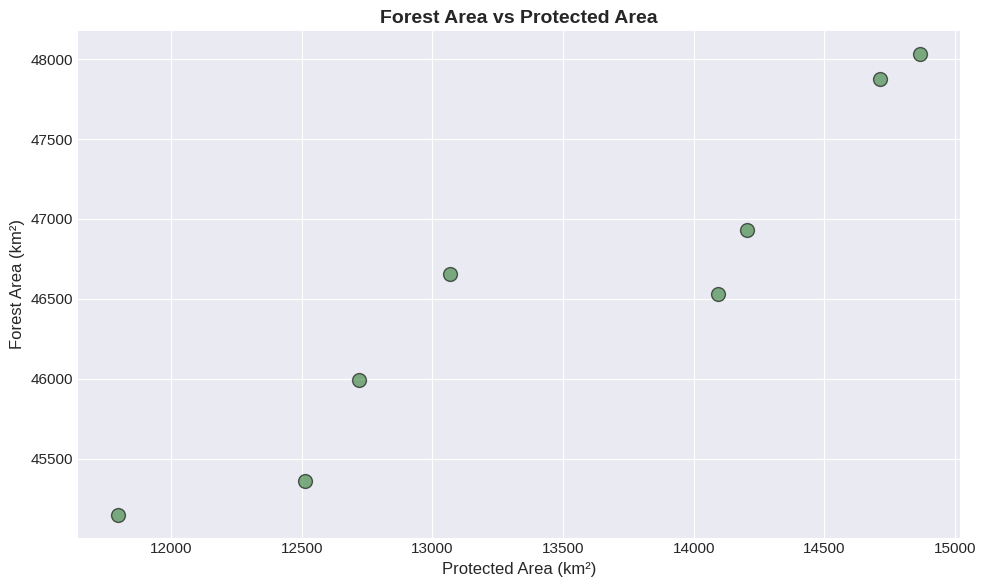

In [39]:
# Scatter plot showing relationship between two variables
plt.figure(figsize=(10, 6))
plt.scatter(df['Protected_Area_km2'], df['Forest_Area_km2'], 
            s=100, alpha=0.6, color='#2E7D32', edgecolors='black', linewidth=1)

plt.title('Forest Area vs Protected Area', fontsize=14, fontweight='bold')
plt.xlabel('Protected Area (km²)', fontsize=12)
plt.ylabel('Forest Area (km²)', fontsize=12)

plt.tight_layout()
plt.show()

## Multi-Panel Plots
Create multiple plots in one figure for side-by-side comparisons:


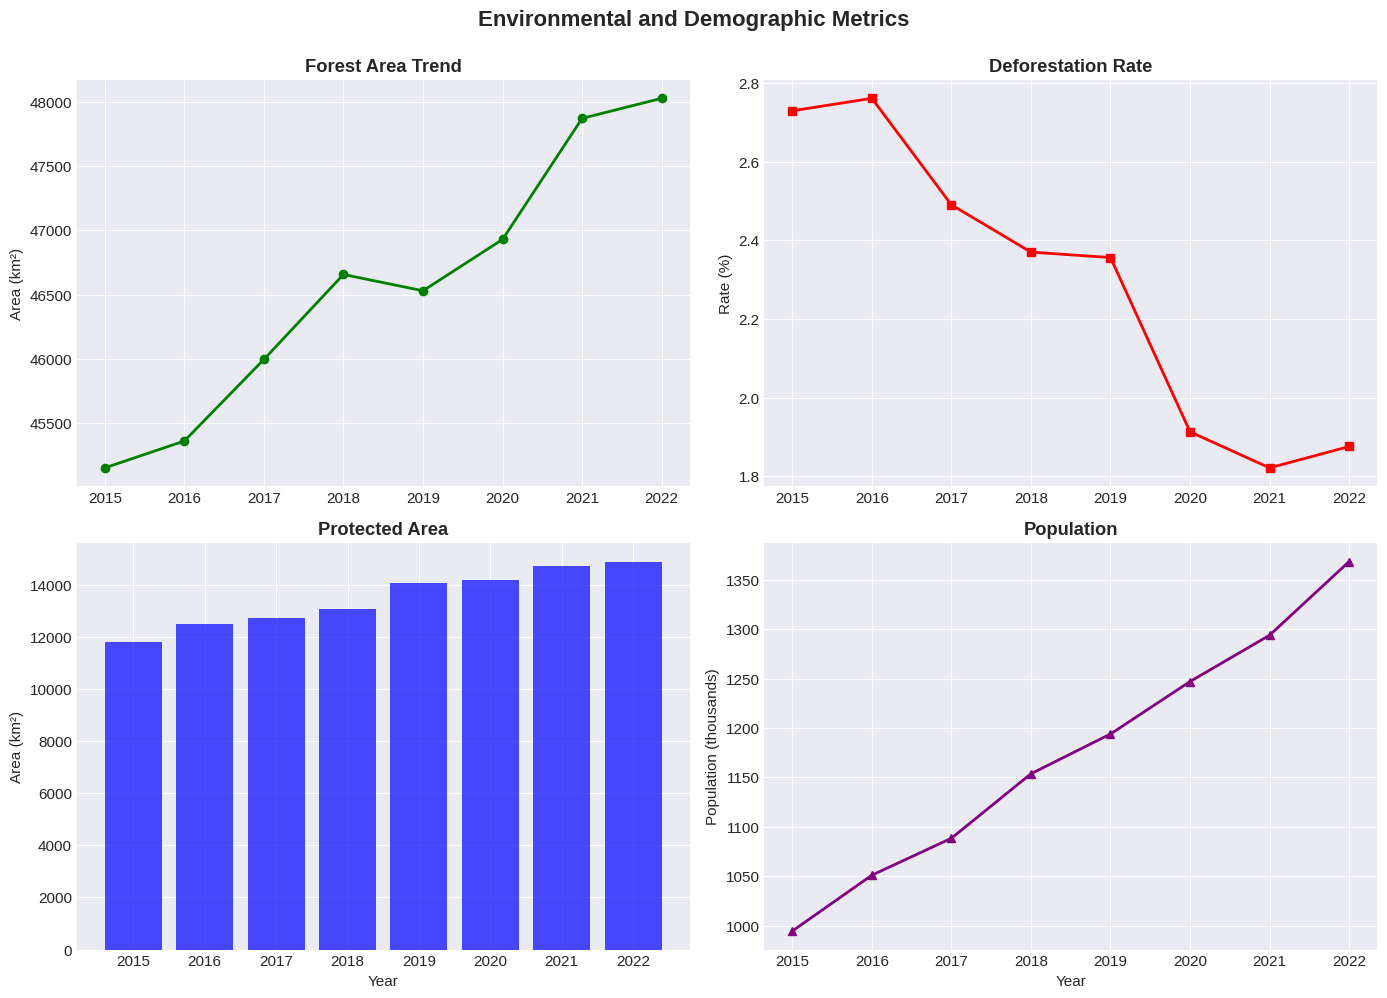

In [27]:
# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Forest Area (top-left)
axes[0, 0].plot(df['Year'], df['Forest_Area_km2'], marker='o', color='green', linewidth=2)
axes[0, 0].set_title('Forest Area Trend', fontweight='bold')
axes[0, 0].set_ylabel('Area (km²)')

# Plot 2: Deforestation Rate (top-right)
axes[0, 1].plot(df['Year'], df['Deforestation_Rate_%'], marker='s', color='red', linewidth=2)
axes[0, 1].set_title('Deforestation Rate', fontweight='bold')
axes[0, 1].set_ylabel('Rate (%)')

# Plot 3: Protected Area (bottom-left)
axes[1, 0].bar(df['Year'], df['Protected_Area_km2'], color='blue', alpha=0.7)
axes[1, 0].set_title('Protected Area', fontweight='bold')
axes[1, 0].set_ylabel('Area (km²)')
axes[1, 0].set_xlabel('Year')

# Plot 4: Population (bottom-right)
axes[1, 1].plot(df['Year'], df['Population']/1000, marker='^', color='purple', linewidth=2)
axes[1, 1].set_title('Population', fontweight='bold')
axes[1, 1].set_ylabel('Population (thousands)')
axes[1, 1].set_xlabel('Year')

# Add overall title
fig.suptitle('Environmental and Demographic Metrics', fontsize=16, fontweight='bold', y=0.995)

# Adjust spacing
plt.tight_layout()
plt.show()

## Customization and Styling

Make your plots publication-ready with careful styling:

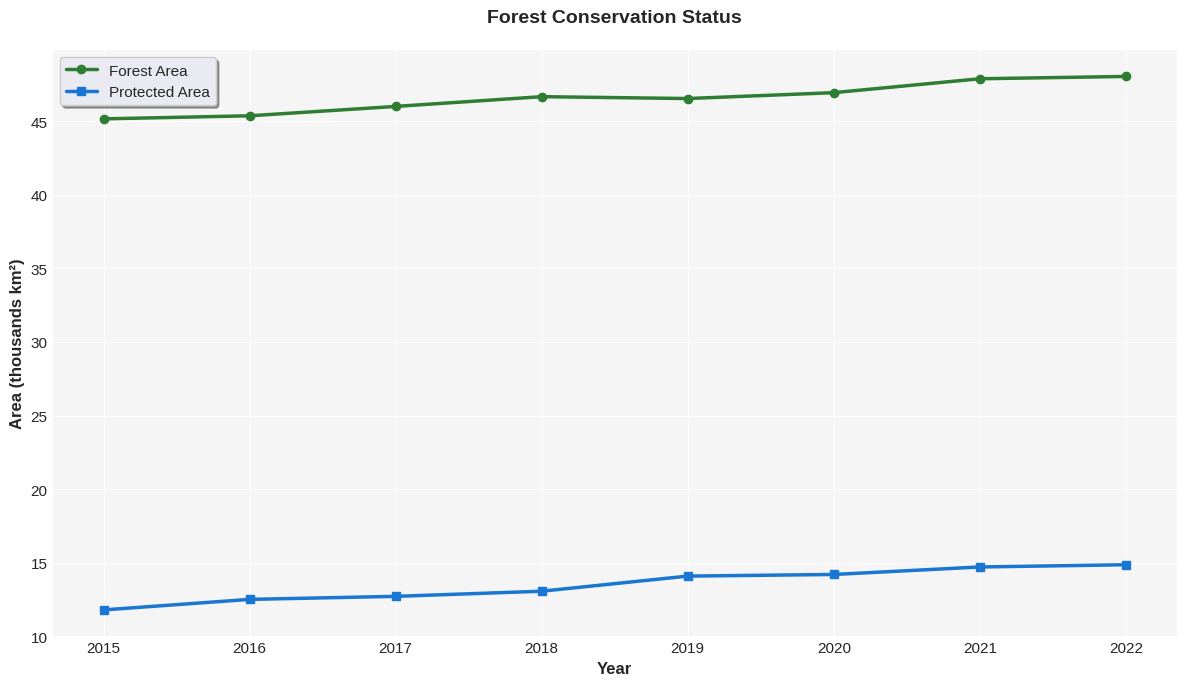

In [28]:
# Professional-looking plot with custom styling
fig, ax = plt.subplots(figsize=(12, 7))

# Plot multiple lines
ax.plot(df['Year'], df['Forest_Area_km2']/1000, 
        marker='o', linewidth=2.5, label='Forest Area', color='#2E7D32')
ax.plot(df['Year'], df['Protected_Area_km2']/1000, 
        marker='s', linewidth=2.5, label='Protected Area', color='#1976D2')

# Customize appearance
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Area (thousands km²)', fontsize=12, fontweight='bold')
ax.set_title('Forest Conservation Status', fontsize=14, fontweight='bold', pad=20)

# Customize legend
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)

# Add subtle background color
ax.set_facecolor('#F5F5F5')
fig.patch.set_facecolor('white')

# Customize spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

### Colorblind-Friendly Palettes

Always consider accessibility when choosing colors:


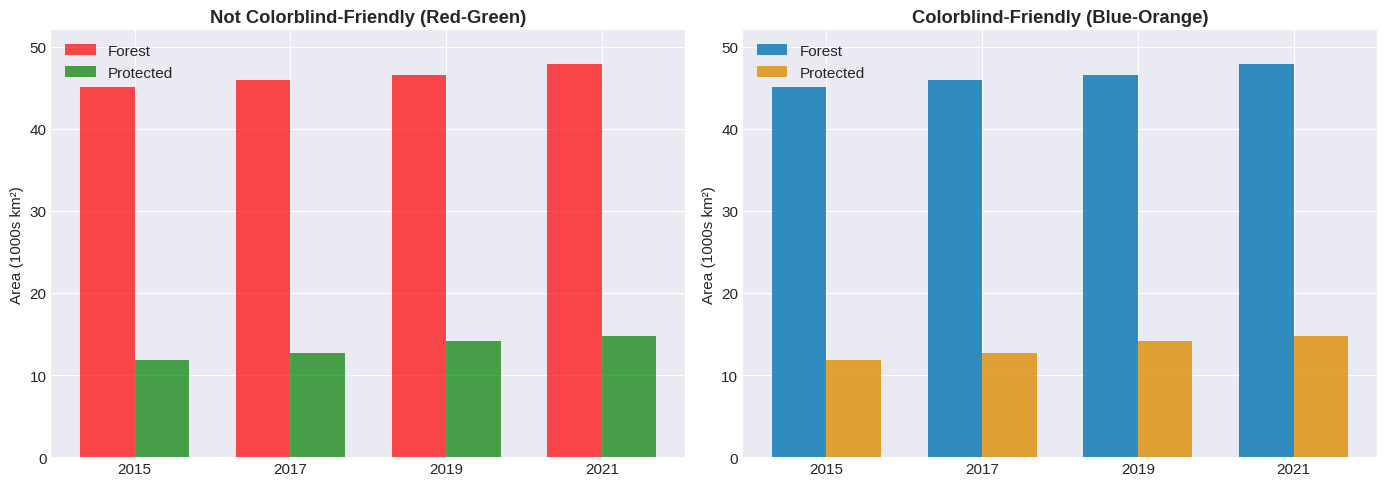

In [44]:
# Colorblind-friendly color palette
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data for comparison - use values on comparable scales
categories = df['Year'].astype(str).values
# Scale forest and protected areas to comparable units (in thousands km²)
values1 = (df['Forest_Area_km2']/1000).values
values2 = (df['Protected_Area_km2']/1000).values

# Plot 1: NOT colorblind-friendly (red-green)
width = 0.35
x = np.arange(len(categories[::2]))
axes[0].bar(x - width/2, values1[::2], width, color='red', label='Forest', alpha=0.7)
axes[0].bar(x + width/2, values2[::2], width, color='green', label='Protected', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories[::2])
axes[0].set_ylabel('Area (1000s km²)')
axes[0].set_title('Not Colorblind-Friendly (Red-Green)', fontweight='bold')
axes[0].set_ylim(0, 52)  # Add space at top for legend
axes[0].legend(loc='upper left')

# Plot 2: Colorblind-friendly (blue-orange)
axes[1].bar(x - width/2, values1[::2], width, color='#0173B2', label='Forest', alpha=0.8)
axes[1].bar(x + width/2, values2[::2], width, color='#DE8F05', label='Protected', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories[::2])
axes[1].set_ylabel('Area (1000s km²)')
axes[1].set_title('Colorblind-Friendly (Blue-Orange)', fontweight='bold')
axes[1].set_ylim(0, 52)  # Add space at top for legend
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## Exporting Charts

✓ Saved: forest_trend.png (PNG - 300 DPI)
✓ Saved: forest_trend.pdf (PDF - Vector)
✓ Saved: forest_trend.svg (SVG - Editable)


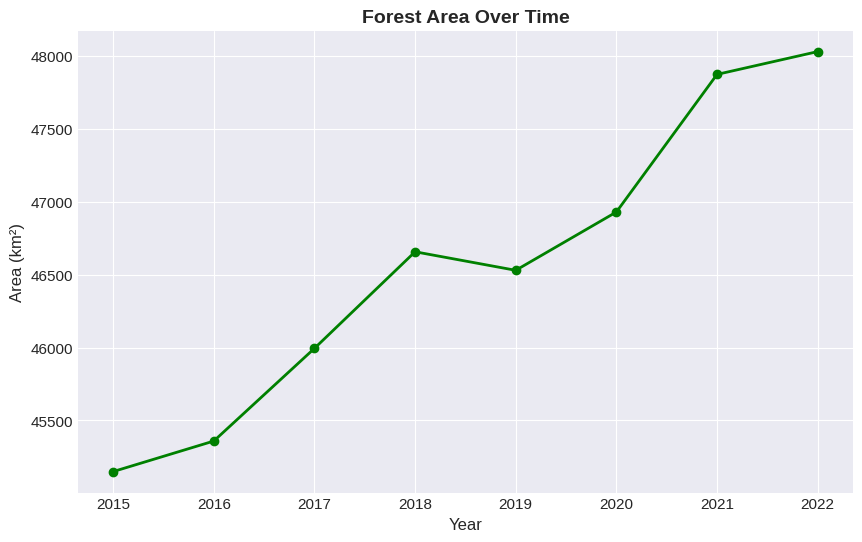

In [49]:
# Create a simple plot for demonstration
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['Year'], df['Forest_Area_km2'], marker='o', linewidth=2, color='green')
ax.set_title('Forest Area Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (km²)', fontsize=12)

# Save in different formats
# PNG (good for screen, presentations)
fig.savefig('forest_trend.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Saved: forest_trend.png (PNG - 300 DPI)")

# PDF (vector format, good for publishing)
fig.savefig('forest_trend.pdf', format='pdf', bbox_inches='tight', facecolor='white')
print("✓ Saved: forest_trend.pdf (PDF - Vector)")

# SVG (editable vector format)
fig.savefig('forest_trend.svg', format='svg', bbox_inches='tight', facecolor='white')
print("✓ Saved: forest_trend.svg (SVG - Editable)")

plt.show()

## Report Creation

Create a comprehensive analysis dashboard for environmental monitoring data that's ready to share with clients.


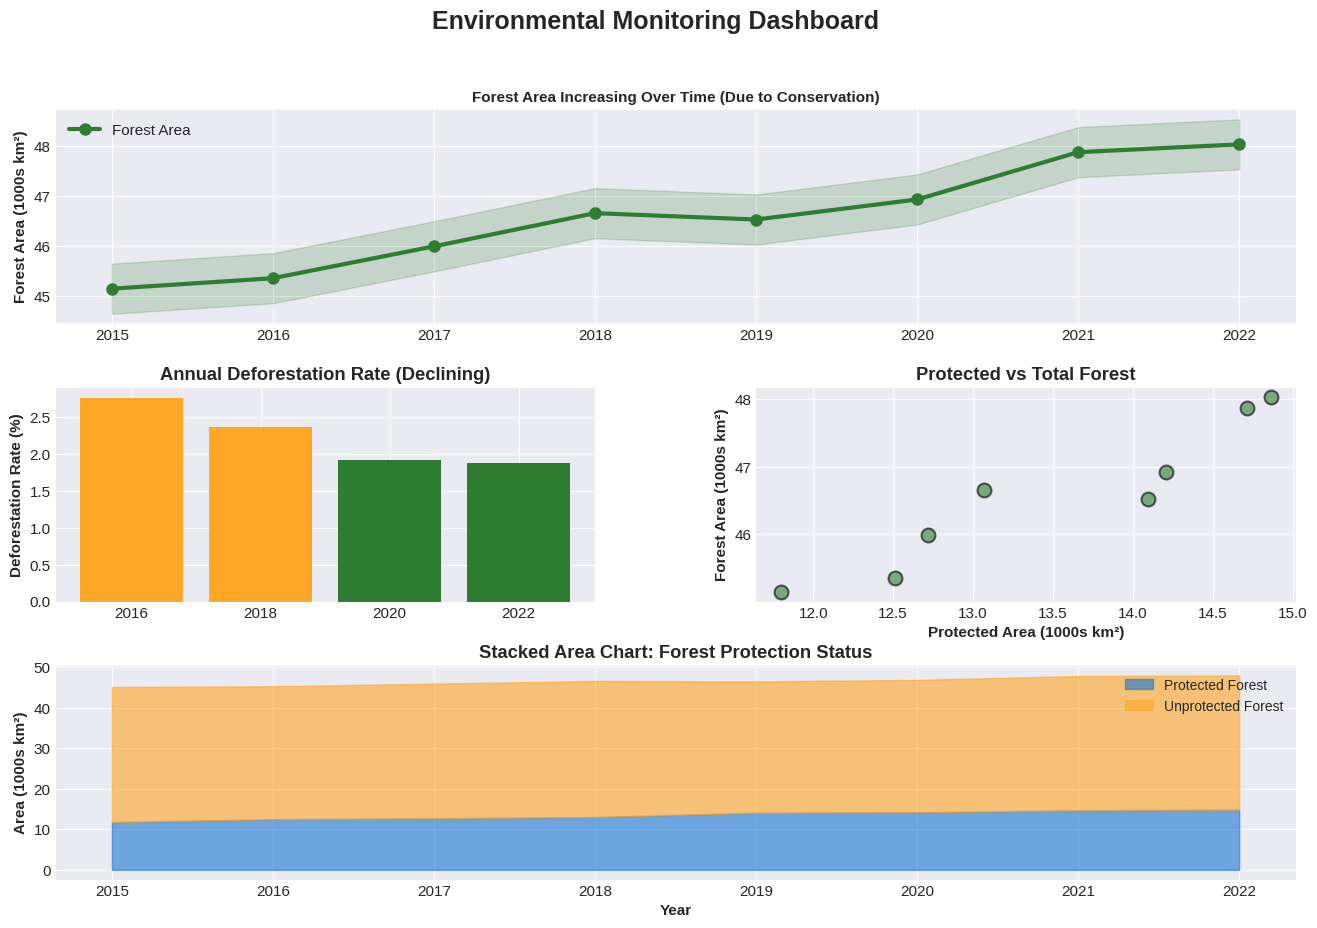

In [47]:
# Create a comprehensive publication-ready dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Environmental Monitoring Dashboard', fontsize=18, fontweight='bold', y=0.98)

# Plot 1: Main trend
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['Year'], df['Forest_Area_km2']/1000, marker='o', linewidth=3, 
         label='Forest Area', color='#2E7D32', markersize=8)
ax1.fill_between(df['Year'], df['Forest_Area_km2']/1000 - 0.5, df['Forest_Area_km2']/1000 + 0.5,
                 alpha=0.2, color='#2E7D32')
ax1.set_ylabel('Forest Area (1000s km²)', fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_title('Forest Area Increasing Over Time (Due to Conservation)', fontweight='bold', fontsize=11)

# Plot 2: Bar chart
ax2 = fig.add_subplot(gs[1, 0])
subset_years = df[df['Year'].isin([2016, 2018, 2020, 2022])]
bars = ax2.bar(subset_years['Year'].astype(str), subset_years['Deforestation_Rate_%'], 
               color=['#2E7D32' if x < 2.3 else '#FFA726' for x in subset_years['Deforestation_Rate_%']])
ax2.set_ylabel('Deforestation Rate (%)', fontweight='bold')
ax2.set_title('Annual Deforestation Rate (Declining)', fontweight='bold')

# Plot 3: Scatter
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(df['Protected_Area_km2']/1000, df['Forest_Area_km2']/1000, 
            s=100, alpha=0.6, color='#2E7D32', edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Protected Area (1000s km²)', fontweight='bold')
ax3.set_ylabel('Forest Area (1000s km²)', fontweight='bold')
ax3.set_title('Protected vs Total Forest', fontweight='bold')

# Plot 4: Area chart
ax4 = fig.add_subplot(gs[2, :])
# Show protected area at the bottom, and remaining unprotected forest on top
protected_scaled = df['Protected_Area_km2']/1000
unprotected_forest = (df['Forest_Area_km2'] - df['Protected_Area_km2'])/1000

ax4.fill_between(df['Year'], 0, protected_scaled, 
                 alpha=0.6, label='Protected Forest', color='#1976D2')
ax4.fill_between(df['Year'], protected_scaled, protected_scaled + unprotected_forest, 
                 alpha=0.6, label='Unprotected Forest', color='#FFA726')
ax4.set_xlabel('Year', fontweight='bold')
ax4.set_ylabel('Area (1000s km²)', fontweight='bold')
ax4.set_title('Stacked Area Chart: Forest Protection Status', fontweight='bold')
ax4.legend(loc='upper right', fontsize=10)

plt.savefig('environmental_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Seaborn

Seaborn is built on top of matplotlib and provides high-level functions for creating beautiful statistical visualizations with minimal code.

Some advantages of Seaborn include

- Beautiful default themes and color palettes
- Statistical estimation and visualization
- Dataset-oriented API that works directly with DataFrames
- Specialized plots like heatmaps, violin plots, and pair plots
- Built-in support for categorical data

### Correlation Matrix
Correlation matrices are excellent for visualizing relationships between multiple variables. Value with a strong positive correlation close to one appear as dark red whereas values with a negative correlation appear as dark blue.

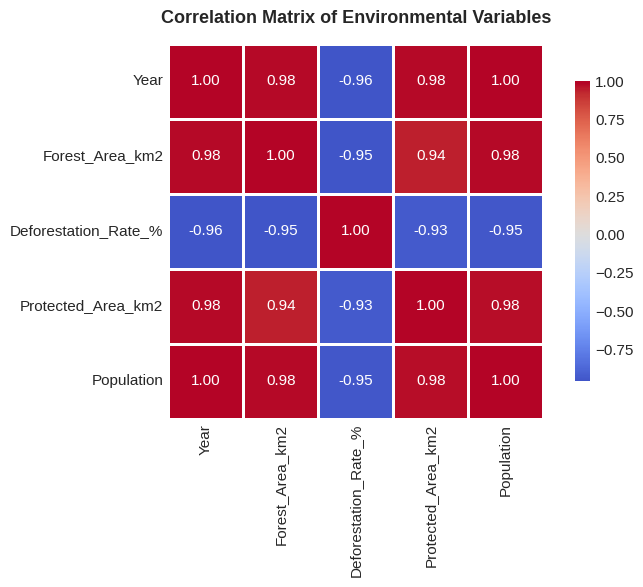

Interpretation: Values close to +1 (dark red) indicate strong positive correlation.
Values close to -1 (dark blue) indicate strong negative correlation.


In [ ]:
# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Environmental Variables', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Linear Regression
Show relationships and trends with automatic statistical estimation. In this graph, the shaded area shows the 95% confidence interval for the regression.

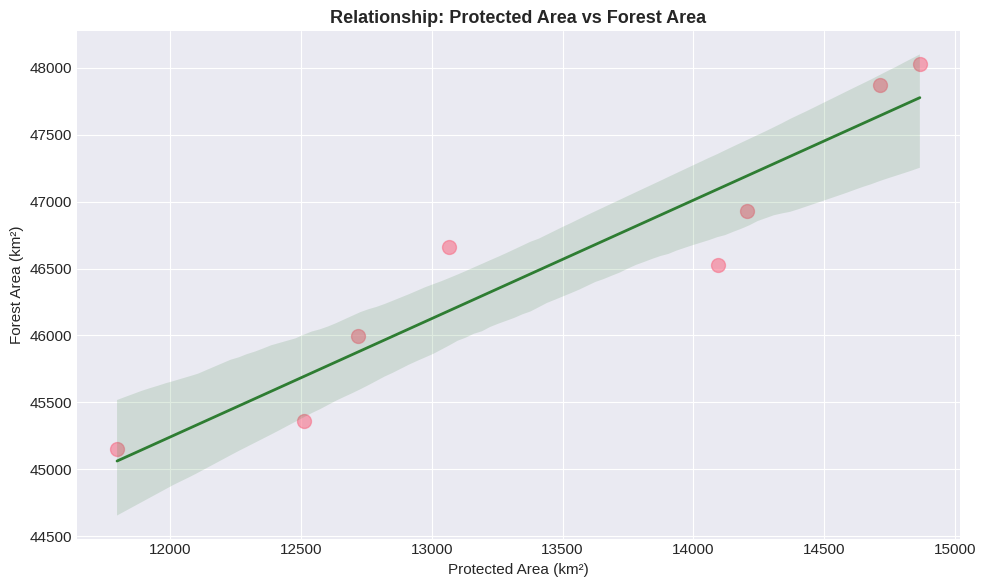

The shaded area shows the 95% confidence interval for the regression line.


In [ ]:
# Regression plot with confidence interval
plt.figure(figsize=(10, 6))
sns.regplot(x='Protected_Area_km2', y='Forest_Area_km2', data=df, 
            scatter_kws={'s': 100, 'alpha': 0.6}, 
            line_kws={'linewidth': 2, 'color': '#2E7D32'})

plt.title('Relationship: Protected Area vs Forest Area', fontsize=13, fontweight='bold')
plt.xlabel('Protected Area (km²)', fontsize=11)
plt.ylabel('Forest Area (km²)', fontsize=11)
plt.tight_layout()
plt.show()

### Pair Plot

View all pairwise relationships in your dataset at once:


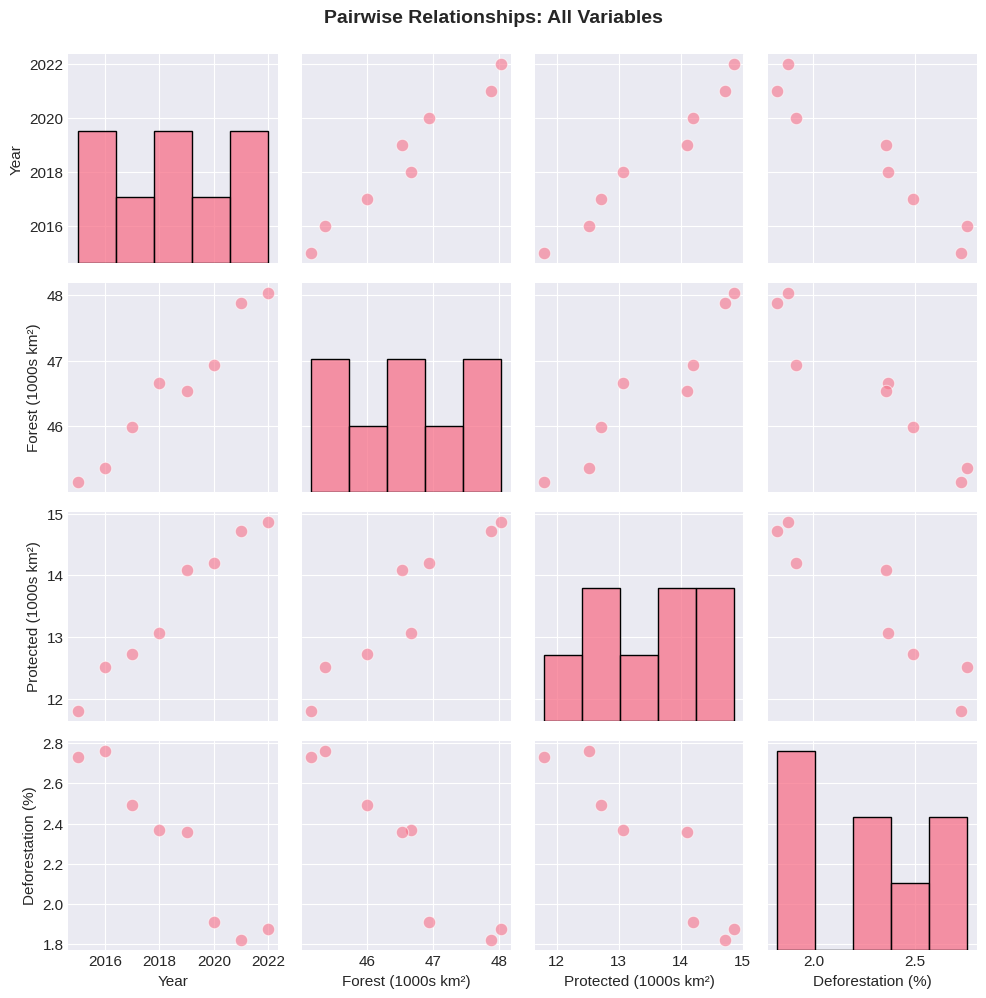

In [48]:
# Pair plot - shows all relationships
selected_cols = ['Year', 'Forest_Area_km2', 'Protected_Area_km2', 'Deforestation_Rate_%']
df_subset = df[selected_cols].copy()

# Scale for better visualization
df_subset['Forest_Area_km2'] = df_subset['Forest_Area_km2'] / 1000  # Convert to thousands
df_subset['Protected_Area_km2'] = df_subset['Protected_Area_km2'] / 1000
df_subset = df_subset.rename(columns={
    'Forest_Area_km2': 'Forest (1000s km²)',
    'Protected_Area_km2': 'Protected (1000s km²)',
    'Deforestation_Rate_%': 'Deforestation (%)'
})

pair_plot = sns.pairplot(df_subset, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 80},
                         diag_kws={'bins': 5, 'edgecolor': 'black'})

pair_plot.fig.suptitle('Pairwise Relationships: All Variables', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Quick Reference
{numref}`choices` shows what situations to use each library.

:::{table} When to Use Each Library
:label: choices
:align: center

| Task | Best Choice | Why |
|------|-------------|-----|
| Quick exploration | Pandas `.plot()` | Minimal code, immediate feedback |
| Fine-grained control | Matplotlib | Complete customization, precise positioning |
| Statistical visualizations | Seaborn | Built-in stats, beautiful defaults |
| Categorical data | Seaborn | Better handling of categories |
| Complex multi-panel layouts | Matplotlib | More control over GridSpec |
| Correlation/relationship analysis | Seaborn | Heatmaps, pair plots, regression |
:::

Pandas vs Matplotlib vs Seaborn examples:

```python
# PANDAS - Quick and simple
df.plot(x='Year', y='Value', kind='line')

# MATPLOTLIB - Fine control
fig, ax = plt.subplots()
ax.plot(df['Year'], df['Value'])
ax.set_title('My Title')
# ... extensive customization

# SEABORN - Beautiful statistics
sns.regplot(x='X', y='Y', data=df)
sns.heatmap(corr_matrix)
```

## Resources

### Documentation
- **Matplotlib:** https://matplotlib.org/stable/index.html
- **Pandas Plotting:** https://pandas.pydata.org/docs/user_guide/visualization.html
- **Seaborn:** https://seaborn.pydata.org/

### Recommended Palettes
- **Sequential (continuous data):** viridis, plasma, inferno, coolwarm
- **Diverging (data with center):** RdBu, RdYlBu, coolwarm
- **Qualitative (categories):** Set2, husl, deep, pastel
- **Colorblind-friendly:** viridis, cividis

### Color Resources
- ColorBrewer: https://colorbrewer2.org/
- Colorblind simulator: https://www.color-blindness.com/coblis-color-blindness-simulator/